In [2]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [3]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = 'data_demo/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)

In [4]:
for i in val_loader:
    energy = i[0]
    point = i[1][0]
    momentum = i[1][1]
    print(i[0].shape)
    print(i[1][0].shape)
    print(i[1][1].shape)
    break

torch.Size([32, 1, 30, 30])
torch.Size([32, 2])
torch.Size([32, 3])


In [85]:
ticks = list(range(-20, 20 + 1, 5))
ticks

[-20, -15, -10, -5, 0, 5, 10, 15, 20]

In [86]:
from mpl_toolkits.axes_grid1 import ImageGrid

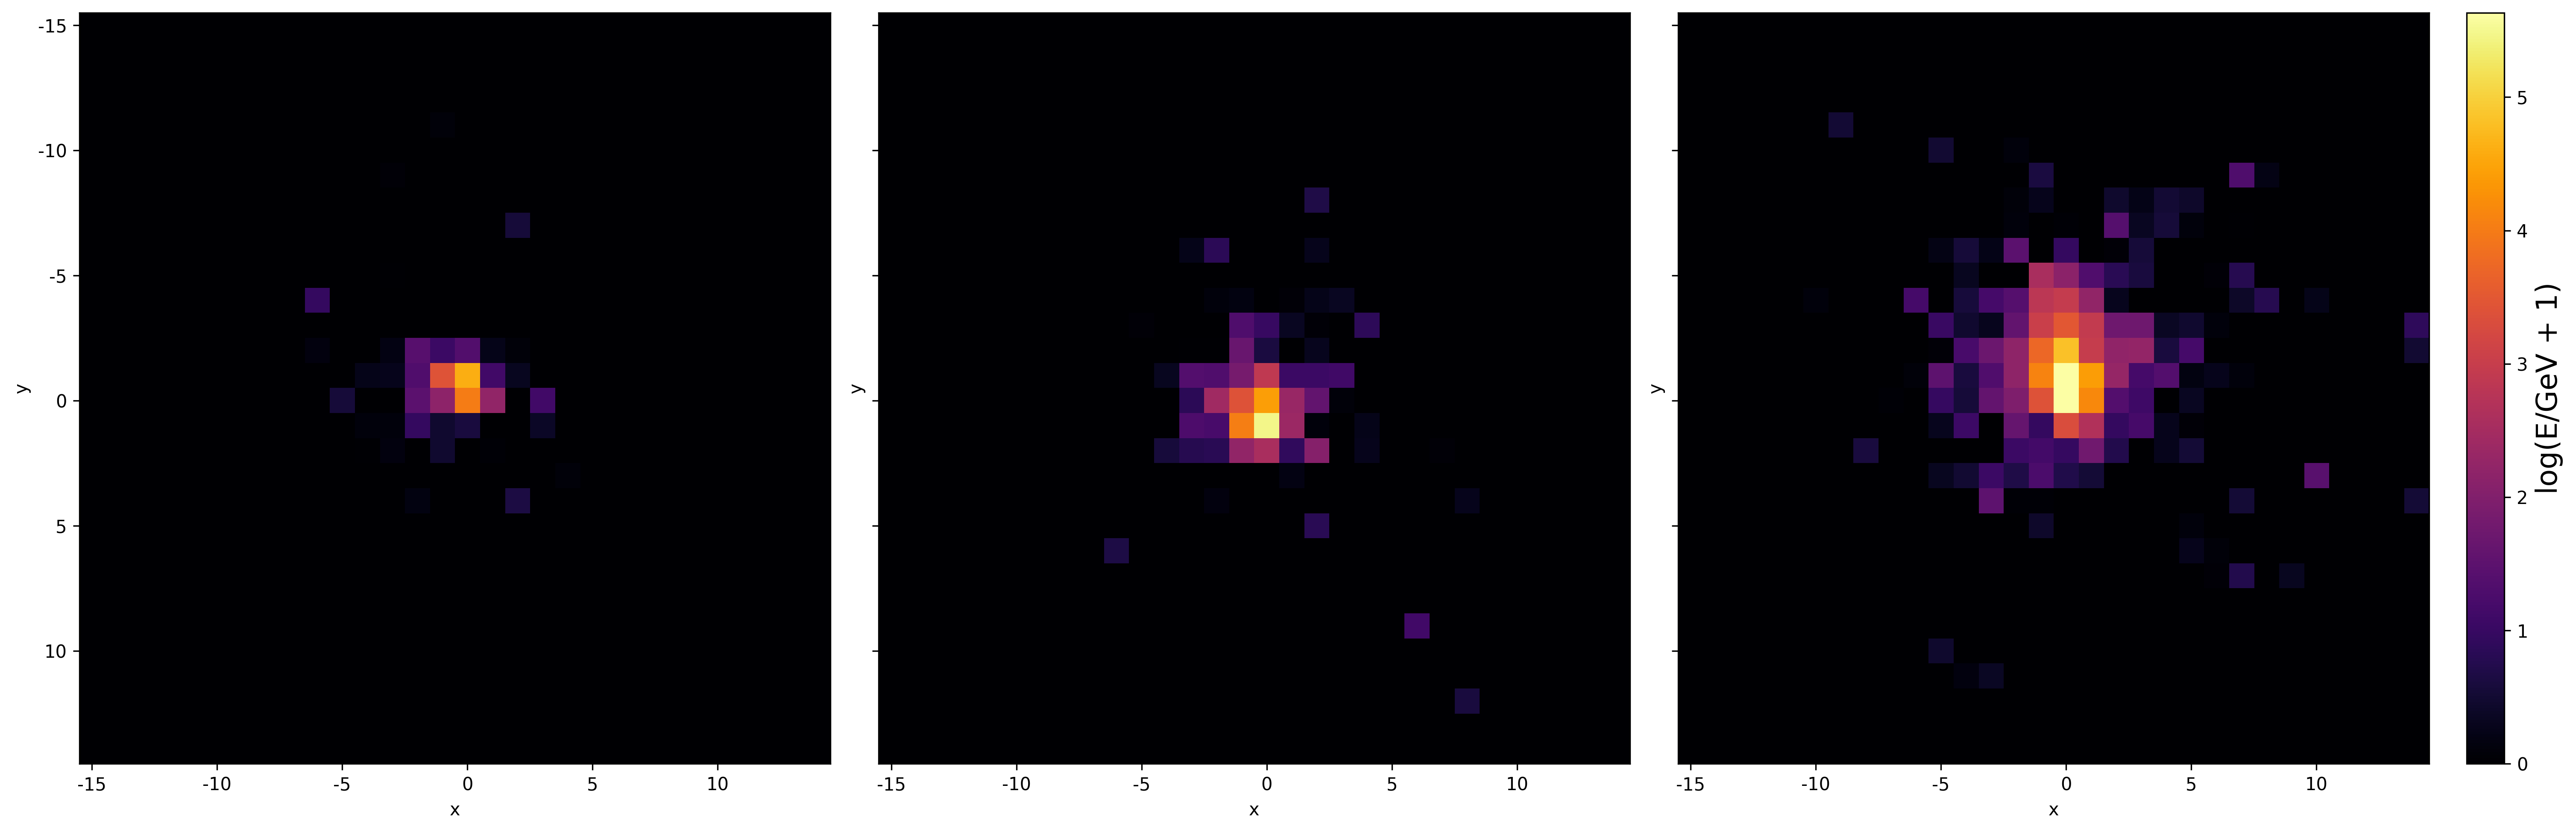

In [88]:
fig, axs = plt.subplots(1, 3, layout='constrained', sharex=True, sharey=True, dpi=300, figsize=(20, 14))
vmin, vmax = min(energy[0].min(), energy[1].min(), energy[2].min()), max(energy[0].max(), energy[1].max(), energy[2].max())
for i, k in enumerate([1, 3, 5]):
    im = axs[i].imshow(np.transpose(energy[k], (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[i].set_yticklabels(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].set_ylabel('y')
    axs[i].set_xlabel('x')
cbar = fig.colorbar(im, fraction=0.05)
cbar.set_label('log(E/GeV + 1)', size=16)
plt.show()
fig.savefig('/Users/sasaatlasov/Desktop/DiffusionDipolma/real.pdf', bbox_inches = "tight")

In [37]:
from diffusion import DiffusionModel

dm = DiffusionModel(500, 16)
dm.load_state_dict(torch.load('checkpoints/t500.pt', map_location=torch.device('cpu')))
dm.eval();

In [96]:
x = torch.randn(1, 1, 30, 30)
dm(x)

TypeError: forward() missing 2 required positional arguments: 'm' and 'p'

In [106]:
energy.shape

torch.Size([32, 1, 30, 30])

In [119]:
from unet_small import UnetModel
model = UnetModel(1, 1, 16)

In [130]:
from torchview import draw_graph

model_graph = draw_graph(model, input_size=[(1, 1, 30, 30), [1, 3], [1, 2], [1, 1]], device='cpu')
model_graph.visual_graph

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [125]:
from torchsummary import summary

summary(model, [(1, 30, 30), [3], [2], [1]])

Layer (type:depth-idx)                   Output Shape              Param #
├─ConvBlock: 1-1                         [-1, 16, 30, 30]          --
|    └─Sequential: 2-1                   [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-1                  [-1, 16, 30, 30]          160
|    |    └─GroupNorm: 3-2               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-3                    [-1, 16, 30, 30]          --
|    └─Sequential: 2-2                   [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-4                  [-1, 16, 30, 30]          2,320
|    |    └─GroupNorm: 3-5               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-6                    [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-7                  [-1, 16, 30, 30]          2,320
|    |    └─GroupNorm: 3-8               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-9                    [-1, 16, 30, 30]          --
├─DownBlock: 1-2                         [-1, 16, 15, 15]          --
|    └─S

Layer (type:depth-idx)                   Output Shape              Param #
├─ConvBlock: 1-1                         [-1, 16, 30, 30]          --
|    └─Sequential: 2-1                   [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-1                  [-1, 16, 30, 30]          160
|    |    └─GroupNorm: 3-2               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-3                    [-1, 16, 30, 30]          --
|    └─Sequential: 2-2                   [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-4                  [-1, 16, 30, 30]          2,320
|    |    └─GroupNorm: 3-5               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-6                    [-1, 16, 30, 30]          --
|    |    └─Conv2d: 3-7                  [-1, 16, 30, 30]          2,320
|    |    └─GroupNorm: 3-8               [-1, 16, 30, 30]          32
|    |    └─ReLU: 3-9                    [-1, 16, 30, 30]          --
├─DownBlock: 1-2                         [-1, 16, 15, 15]          --
|    └─S

In [38]:
samples = dm.sample(momentum, point)

  0%|          | 0/500 [00:00<?, ?it/s]

In [39]:
def compare(idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())

    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    if truncate:
        sampled[sampled < truncate] = 0
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

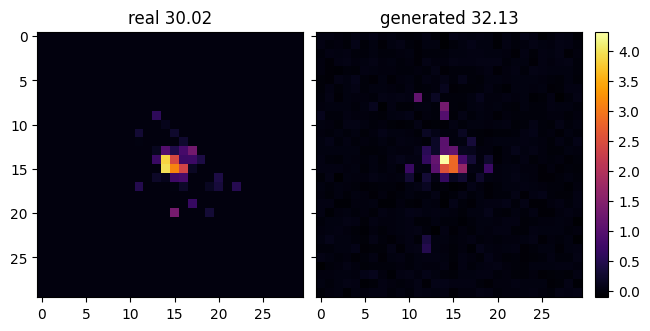

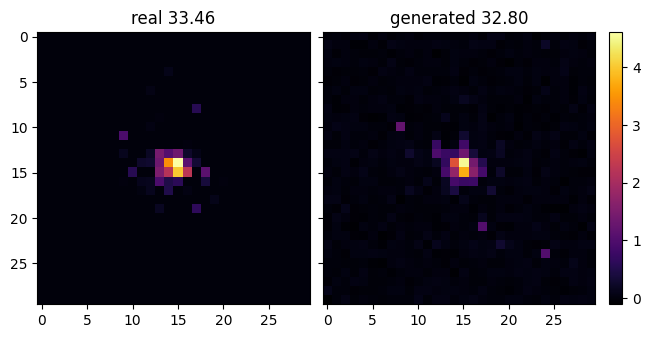

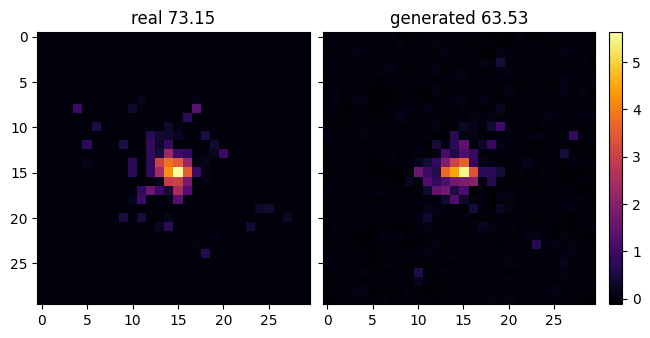

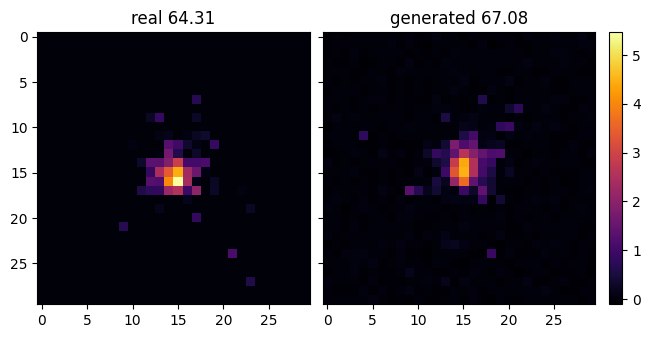

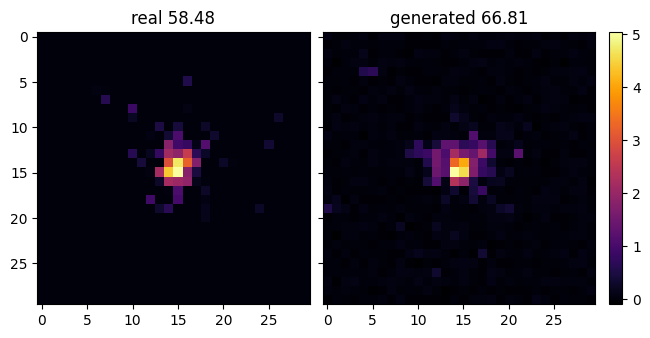

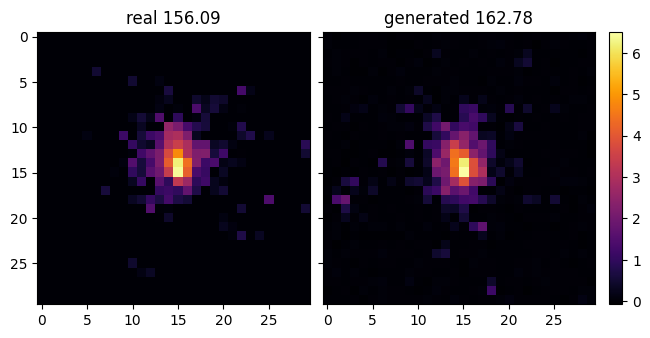

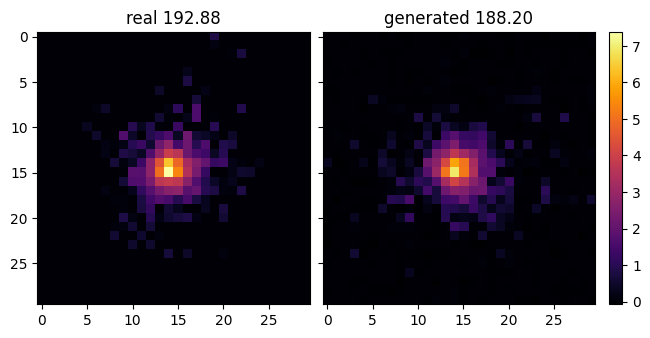

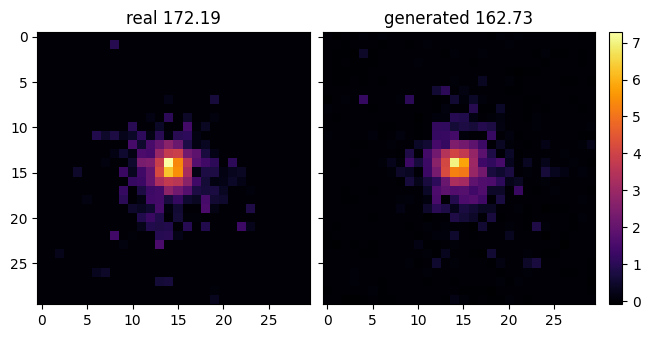

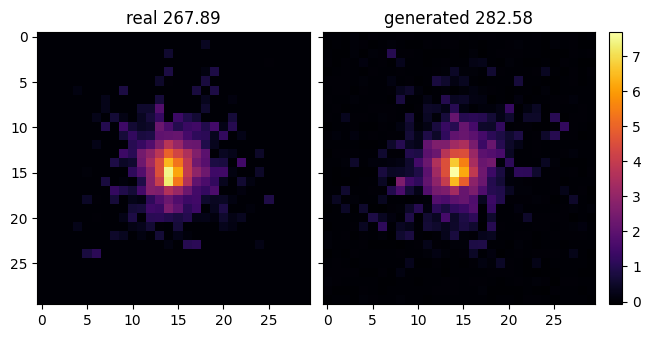

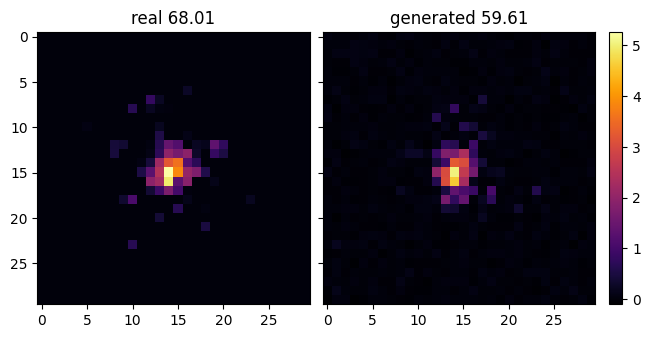

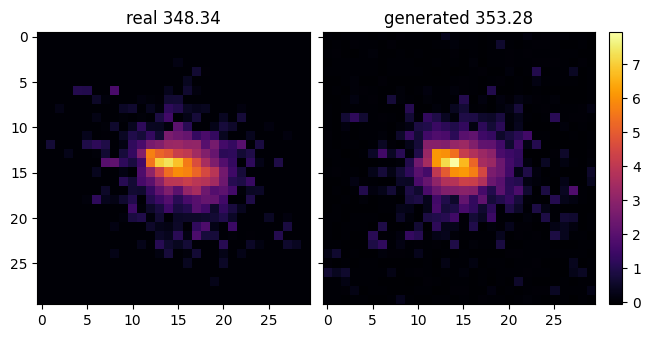

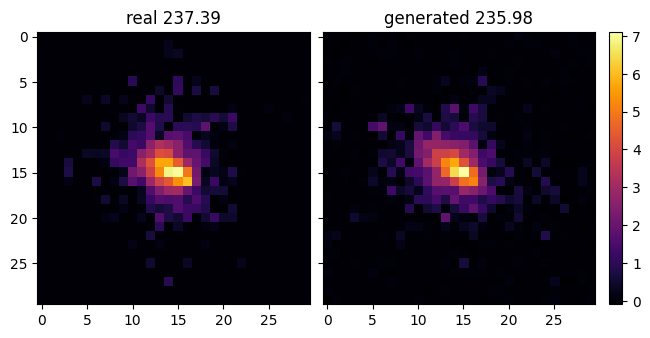

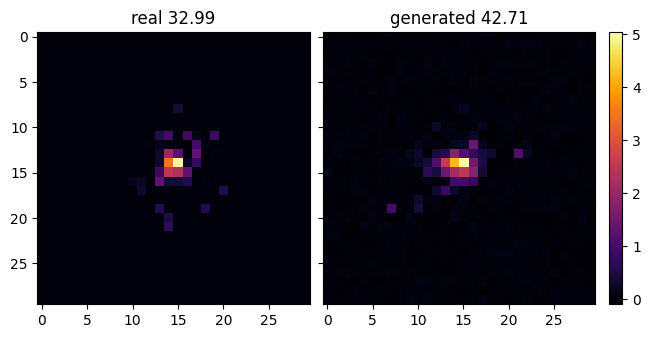

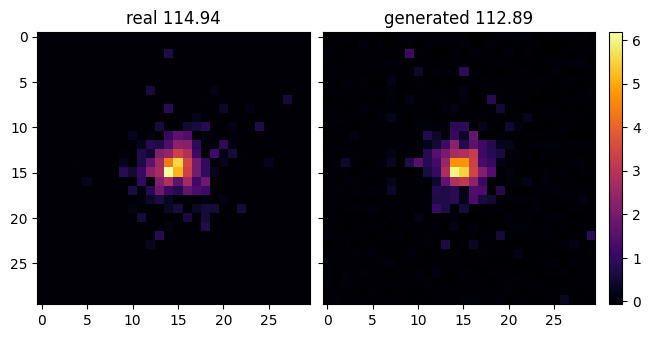

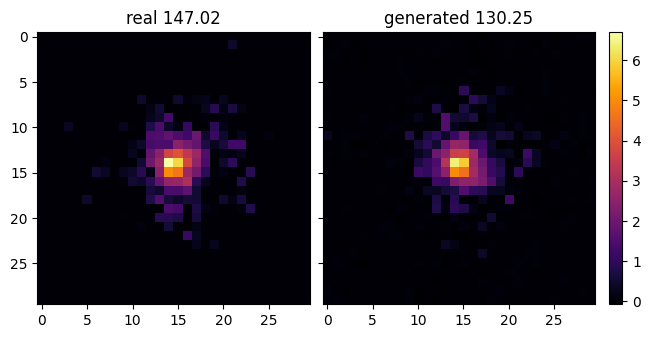

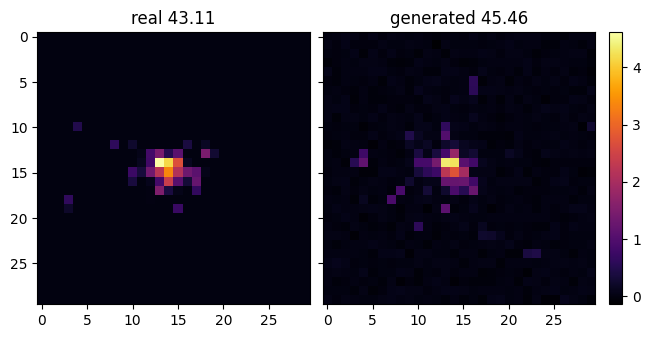

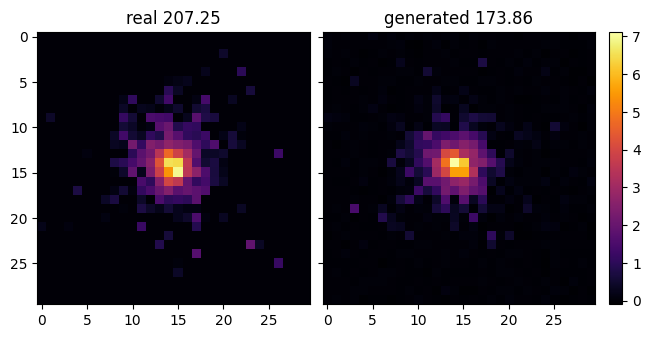

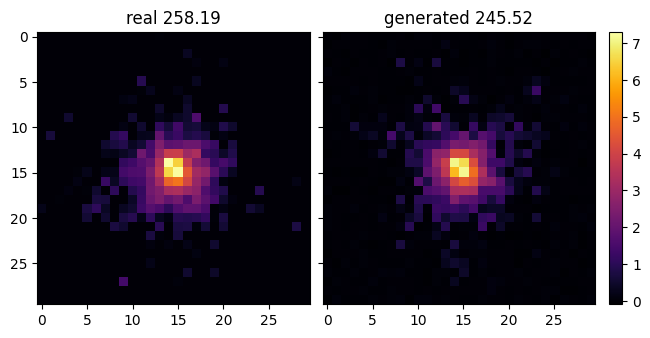

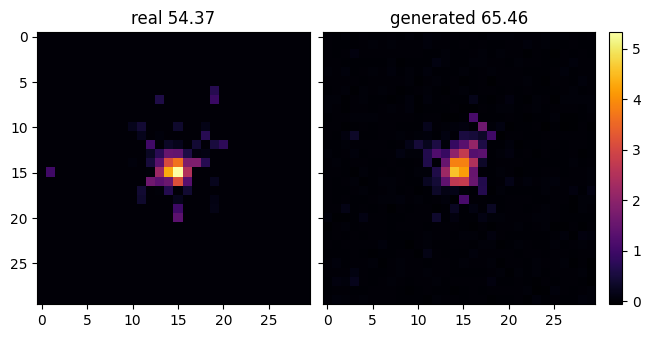

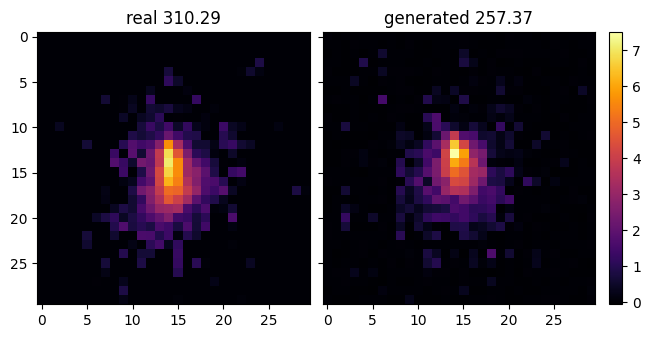

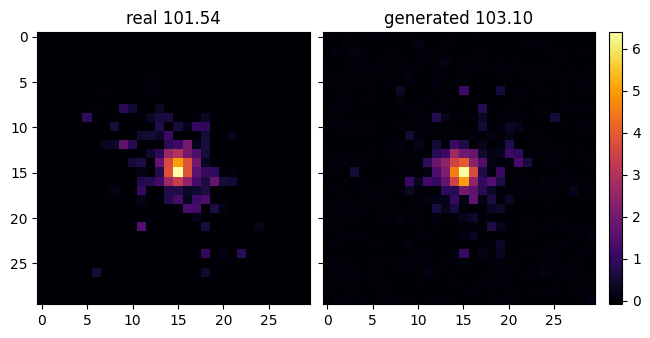

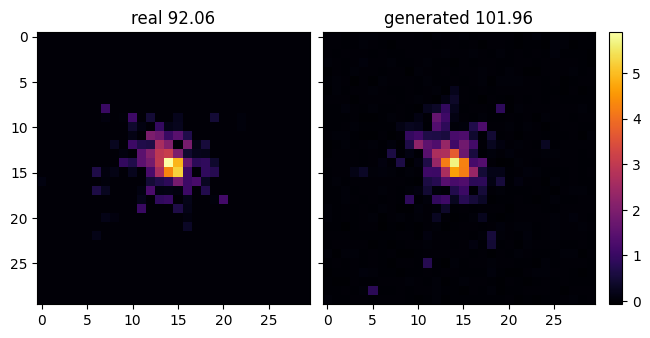

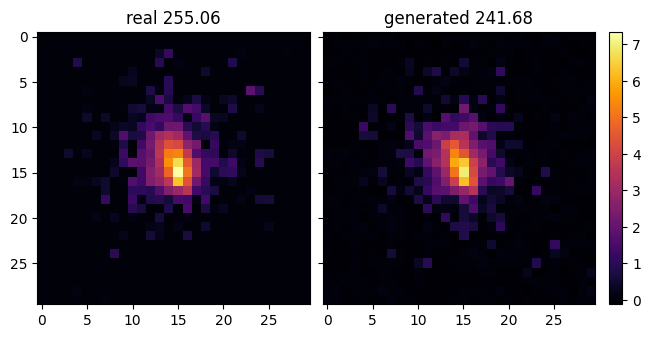

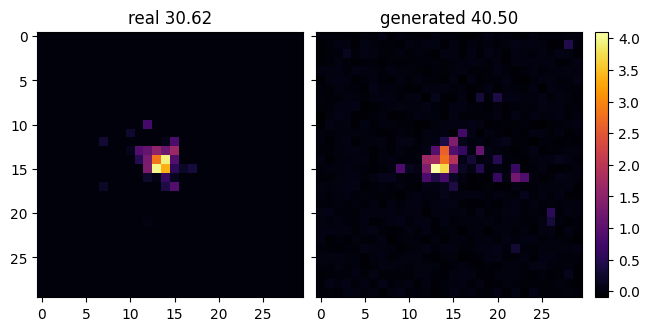

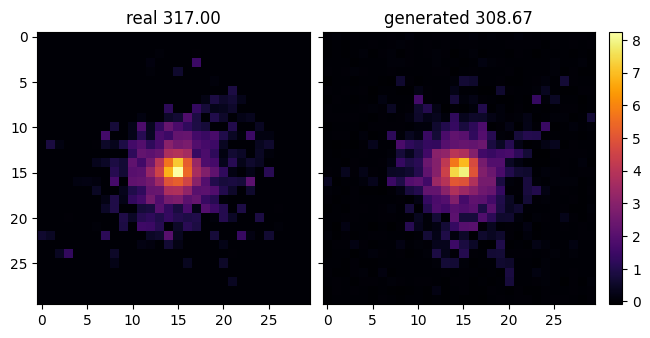

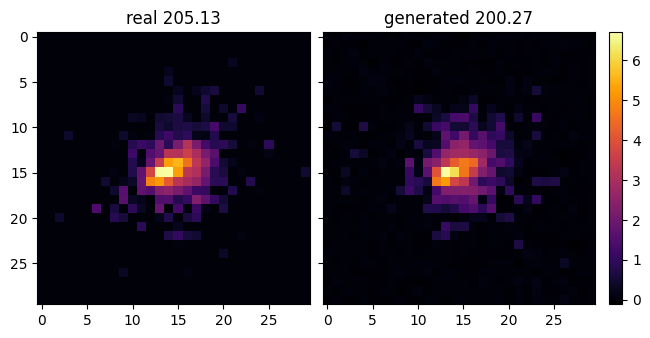

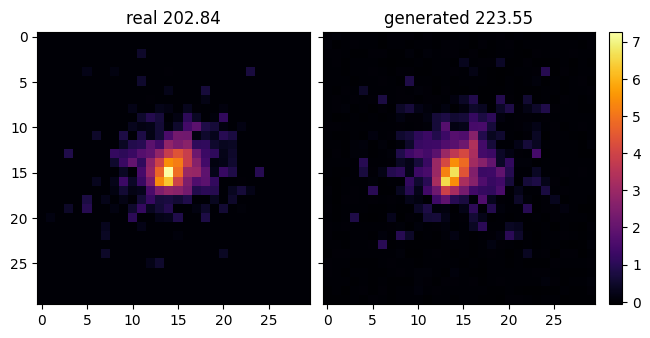

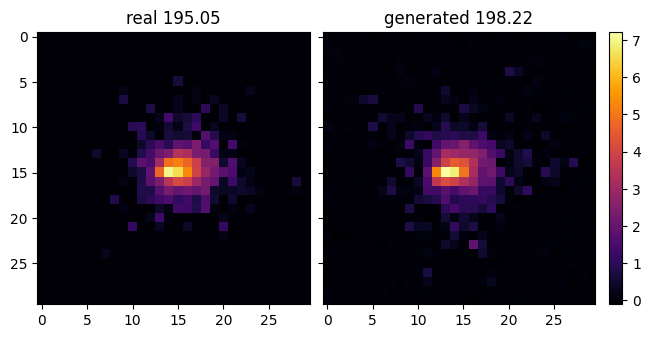

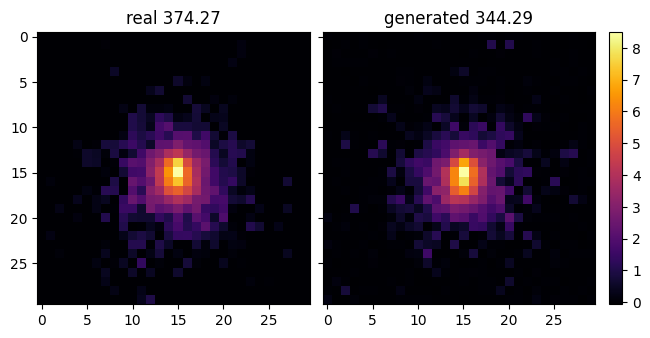

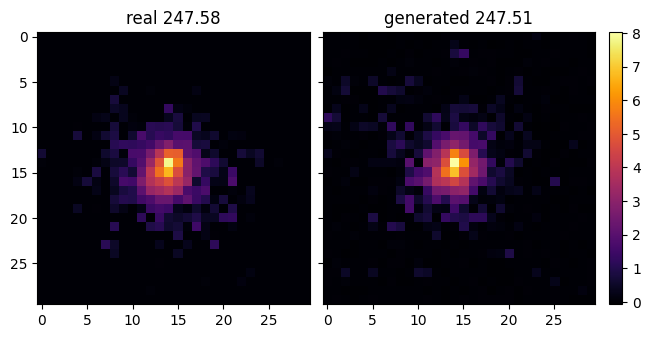

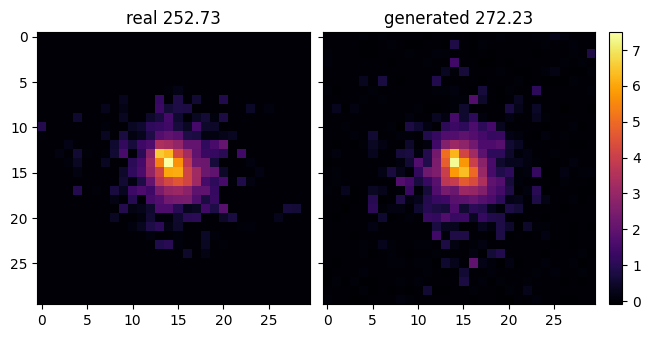

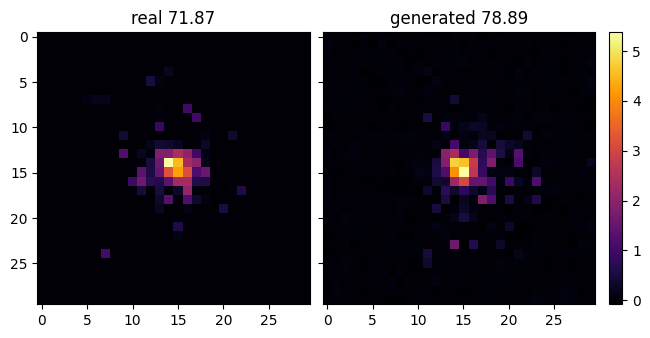

In [40]:
for i in range(32):
    compare(i)